<a href="https://colab.research.google.com/github/Alister44/DTA_2026_DE/blob/main/Unterrichtsaufgaben/pandas_tasks_beginners_DTA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praktische Aufgaben mit pandas für Anfänger

**Ziel:** Grundlegende Fähigkeiten im Umgang mit der pandas-Bibliothek für die Analyse von Tabellendaten erwerben.

**Anweisungen:**
- Bearbeite die Aufgaben der Reihe nach — jede folgende baut auf den vorherigen auf.
- Schreibe nach jeder Aufgabe eine kurze Schlussfolgerung in die Zelle `**Schlussfolgerung:**`.
- Ändere den Code in den Zellen zur Datenvorbereitung nicht.

**Datensatz:** Fiktive Verkaufstabelle eines Online-Shops für das Jahr 2023.


---
## Vorbereitung: Generierung von Testdaten

Führe diese Zelle vor Beginn der Arbeit aus. Ändere den Code nicht.


In [22]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 200

categories = ['Elektronik', 'Kleidung', 'Bücher', 'Lebensmittel', 'Sport']
cities = ['Berlin', 'München', 'Hamburg', 'Köln', 'Frankfurt']
payment_methods = ['Karte', 'Bargeld', 'Online']

df = pd.DataFrame({
    'order_id':        range(1001, 1001 + n),
    'date':            pd.date_range('2023-01-01', periods=n, freq='D')[:n],
    'category':        np.random.choice(categories, n),
    'product':         ['Produkt_' + str(i) for i in np.random.randint(1, 51, n)],
    'city':            np.random.choice(cities, n),
    'quantity':        np.random.randint(1, 10, n),
    'price':           np.round(np.random.uniform(50, 5000, n), 2),
    'payment_method':  np.random.choice(payment_methods, n),
    'rating':          np.random.choice([1, 2, 3, 4, 5, np.nan], n, p=[0.05, 0.1, 0.15, 0.3, 0.3, 0.1]),
    'is_returned':     np.random.choice([True, False], n, p=[0.1, 0.9]),
})

# Fügen wir ein paar fehlende Werte hinzu
df.loc[np.random.choice(df.index, 10, replace=False), 'city'] = np.nan
df.loc[np.random.choice(df.index, 5, replace=False), 'price'] = np.nan

# Berechnen wir den Gesamtbetrag
df['total'] = df['quantity'] * df['price']

print('Daten erfolgreich generiert. Zeilen:', len(df))
print('Spalten:', list(df.columns))


Daten erfolgreich generiert. Zeilen: 200
Spalten: ['order_id', 'date', 'category', 'product', 'city', 'quantity', 'price', 'payment_method', 'rating', 'is_returned', 'total']


---
## Aufgabe 1 (Leicht). Erster Blick auf die Daten

Gib die ersten 10 Zeilen des DataFrames `df` aus und erhalte allgemeine Informationen darüber (Anzahl der Zeilen, Spalten, Datentypen) mit den Methoden `head()` und `info()`.


In [23]:
# Dein Code hier
print(df.iloc[1:3,5:8])
print(df.info())


   quantity    price payment_method
1         6  1086.28          Karte
2         4  1883.84        Bargeld
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        200 non-null    int64         
 1   date            200 non-null    datetime64[ns]
 2   category        200 non-null    object        
 3   product         200 non-null    object        
 4   city            190 non-null    object        
 5   quantity        200 non-null    int64         
 6   price           195 non-null    float64       
 7   payment_method  200 non-null    object        
 8   rating          177 non-null    float64       
 9   is_returned     200 non-null    bool          
 10  total           195 non-null    float64       
dtypes: bool(1), datetime64[ns](1), float64(3), int64(2), object(4)
memory usage: 15.9+ KB
None


**Schlussfolgerung:** *(Schreibe, wie viele Zeilen und Spalten der DataFrame hat, welche Datentypen vorkommen, ob es fehlende Werte gibt)*


---
## Aufgabe 2 (Leicht). Beschreibende Statistik

Verwende die Methode `describe()`, um beschreibende Statistiken der numerischen Spalten zu erhalten. Gib separat das Minimum, Maximum und den Mittelwert der Spalte `price` aus.


In [24]:
# Dein Code hier
df.describe()


,order_id,date,quantity,price,rating,total
count,200.000000,200,200.000000,195.000000,177.000000,195.000000
mean,1100.500000,2023-04-10 12:00:00,4.700000,2500.579641,3.813559,11629.097590
min,1001.000000,2023-01-01 00:00:00,1.000000,139.650000,1.000000,149.350000
25%,1050.750000,2023-02-19 18:00:00,2.000000,1288.215000,3.000000,3893.955000
50%,1100.500000,2023-04-10 12:00:00,5.000000,2517.290000,4.000000,8746.840000
75%,1150.250000,2023-05-30 06:00:00,7.000000,3706.975000,5.000000,16922.420000
max,1200.000000,2023-07-19 00:00:00,9.000000,4950.300000,5.000000,44324.640000
std,57.879185,NaN,2.618066,1380.066748,1.169808,9968.293697


**Schlussfolgerung:** *(Beschreibe die Preisspanne, den Mittelwert, ob es eine deutliche Streuung gibt)*


---
## Aufgabe 3 (Leicht). Fehlende Werte

Finde die Anzahl der fehlenden Werte in jeder Spalte mit `isnull().sum()`. Bestimme, wie viel Prozent der Zeilen mindestens in einer Spalte einen fehlenden Wert haben (`dropna()` und `len()`).


In [25]:
# Dein Code hier
df.isnull().sum()


,0
order_id,0
date,0
category,0
product,0
city,10
quantity,0
price,5
payment_method,0
rating,23
is_returned,0


**Schlussfolgerung:** *(In welchen Spalten gibt es fehlende Werte, wie kritisch ist das für die Analyse)*


---
## Aufgabe 4 (Leicht). Auswahl von Spalten und Zeilen

Erstelle einen neuen DataFrame `df_subset`, der nur die Spalten `order_id`, `category`, `city`, `total` enthält. Gib dann die Zeilen mit den Indizes 10 bis einschließlich 20 mit `.iloc[]` aus.


In [26]:
# Dein Code hier
df_subset = df[['order_id','category', 'city', 'total']]
df_subset.iloc[10:21,1:]



,category,city,total
10,Lebensmittel,Köln,21486.48
11,Bücher,Frankfurt,31368.89
12,Sport,München,7748.40
13,Kleidung,Köln,18787.72
14,Lebensmittel,NaN,1741.50
15,Kleidung,Hamburg,4529.38
16,Lebensmittel,Berlin,10745.84
17,Sport,Hamburg,10001.84
18,Elektronik,Köln,12444.75
19,Lebensmittel,München,13422.92


**Schlussfolgerung:** *(Erkläre den Unterschied zwischen der Spaltenauswahl über eine Liste und über `iloc`)*


---
## Aufgabe 5 (Leicht). Daten filtern

Filtere den DataFrame und erhalte:
1. Alle Bestellungen aus der Kategorie `'Elektronik'`.
2. Alle Bestellungen, bei denen `price` über 2000 liegt.
3. Zurückgegebene Bestellungen (`is_returned == True`) aus der Stadt `'Berlin'`.

Gib die Anzahl der Zeilen für jeden Filter aus.


In [27]:
# Dein Code hier
print("Anteil der Bestellungen aus der Kategorie Elektronik: ")
print(len(df[df['category'] == 'Elektronik'])/len(df)*100)

print("Alle Bestellungen, bei denen price über 2000 liegt")
print(df[df['price'] > 2000])

print("Zurückgegebene Bestellungen (is_returned == True) aus der Stadt 'Berlin'.")
print(df[(df['is_returned'] == True) & (df['city'] == 'Berlin')])

berlin = df[df['city'] == 'Berlin']
berlin_returned = berlin[berlin['is_returned'] == True]
pct = len(berlin_returned) / len(berlin) * 100
print(f"Anteil der zurückgegebenen Bestellungen aus Berlin: {pct}")


Anteil der Bestellungen aus der Kategorie Elektronik: 
21.5
Alle Bestellungen, bei denen price über 2000 liegt
     order_id       date      category     product       city  quantity  \
3        1004 2023-01-04         Sport  Produkt_11       Köln         1   
4        1005 2023-01-05         Sport  Produkt_48       Köln         7   
6        1007 2023-01-07        Bücher  Produkt_33       Köln         4   
7        1008 2023-01-08        Bücher   Produkt_9  Frankfurt         4   
10       1011 2023-01-11  Lebensmittel  Produkt_29       Köln         6   
..        ...        ...           ...         ...        ...       ...   
193      1194 2023-07-13      Kleidung  Produkt_22        NaN         8   
194      1195 2023-07-14  Lebensmittel  Produkt_49    München         1   
195      1196 2023-07-15        Bücher  Produkt_42  Frankfurt         4   
196      1197 2023-07-16        Bücher   Produkt_6  Frankfurt         1   
197      1198 2023-07-17    Elektronik  Produkt_15  Frankfurt   

**Schlussfolgerung:** *(Welcher Anteil der Bestellungen entspricht jedem Kriterium? Was lässt sich über die Rückgaben aus Berlin sagen?)*


---
## Aufgabe 6 (Mittel). Sortieren und Rangfolge

1. Sortiere den DataFrame nach der Spalte `total` absteigend und gib die Top-10 größten Bestellungen aus.
2. Füge eine neue Spalte `rank` hinzu, die die Rangnummer der Bestellung nach Betragsgröße enthält (vom größten zum kleinsten) mit `.rank()`.


In [28]:
# Dein Code hier
df['rank'] = df['total'].rank(ascending=False,method='min')
df.sort_values('total',ascending=False).head(10)



,order_id,date,category,product,city,quantity,price,payment_method,rating,is_returned,total,rank
190,1191,2023-07-10,Kleidung,Produkt_22,Berlin,9,4924.96,Bargeld,4.0,True,44324.64,1.0
58,1059,2023-02-28,Lebensmittel,Produkt_33,München,9,4848.88,Karte,5.0,False,43639.92,2.0
186,1187,2023-07-06,Sport,Produkt_34,Berlin,9,4675.12,Bargeld,5.0,False,42076.08,3.0
55,1056,2023-02-25,Elektronik,Produkt_3,Köln,8,4912.77,Karte,5.0,False,39302.16,4.0
169,1170,2023-06-19,Lebensmittel,Produkt_50,Berlin,8,4739.05,Bargeld,5.0,False,37912.40,5.0
191,1192,2023-07-11,Sport,Produkt_25,München,9,4202.55,Bargeld,4.0,True,37822.95,6.0
193,1194,2023-07-13,Kleidung,Produkt_22,NaN,8,4608.17,Karte,4.0,False,36865.36,7.0
51,1052,2023-02-21,Lebensmittel,Produkt_35,Köln,8,4488.99,Online,4.0,False,35911.92,8.0
25,1026,2023-01-26,Bücher,Produkt_18,Köln,8,4458.11,Karte,3.0,False,35664.88,9.0
143,1144,2023-05-24,Lebensmittel,Produkt_31,Berlin,9,3732.53,Bargeld,5.0,False,33592.77,10.0


**Schlussfolgerung:** *(Wie hoch ist der maximale Bestellbetrag? Aus welchen Kategorien stammen die größten Bestellungen?)*


---
## Aufgabe 7 (Mittel). Gruppierung und Aggregation

Berechne mit `groupby()` für jede Produktkategorie:
- den Gesamtumsatz (Summe von `total`),
- die Anzahl der Bestellungen,
- den durchschnittlichen Preis (`price`).

Sortiere das Ergebnis nach dem Gesamtumsatz.


In [29]:
display(df.groupby('category').agg(total_sum = ('total', 'sum'), total_count = ('total', 'count'), price_mean = ('price','mean')).sort_values('total_sum', ascending=False))
display(df.groupby('category').agg({'total' : 'sum',
                                    'total' : 'count',
                                    'price':'mean'}))

,total_sum,total_count,price_mean
category,,,
Lebensmittel,583761.68,47,2513.979787
Kleidung,474135.61,34,2707.906176
Elektronik,428129.79,43,2334.470698
Sport,400802.56,35,2494.205143
Bücher,380844.39,36,2491.881944


,total,price
category,,
Bücher,36,2491.881944
Elektronik,43,2334.470698
Kleidung,34,2707.906176
Lebensmittel,47,2513.979787
Sport,35,2494.205143


**Schlussfolgerung:** *(Welche Kategorie bringt den größten Umsatz? Stimmt das mit der Anzahl der Bestellungen überein?)*


---
## Aufgabe 8 (Mittel). Umgang mit fehlenden Werten

1. Fülle die fehlenden Werte in der Spalte `price` mit dem Median der Preise der jeweiligen Kategorie (verwende `groupby().transform('median')`).
2. Fülle die fehlenden Werte in der Spalte `city` mit dem String `'Unbekannt'`.
3. Lasse die fehlenden Werte in `rating` unverändert — erkläre warum in der Schlussfolgerung.

Überprüfe, dass es in `price` und `city` keine fehlenden Werte mehr gibt.


In [30]:
display(df[df['price'].isna()])
median_price = df.groupby('category')['price'].transform('median')
display(median_price)
df['price'] = df['price'].fillna(median_price)
df['total'] = df['total'].fillna(df['price']*df['quantity'])
df['city'] = df['city'].fillna('Unbekannt')
display(df[df['rating'].isna()].sort_values('product'))


,order_id,date,category,product,city,quantity,price,payment_method,rating,is_returned,total,rank
22,1023,2023-01-23,Lebensmittel,Produkt_33,München,9,NaN,Karte,5.0,False,NaN,NaN
52,1053,2023-02-22,Lebensmittel,Produkt_19,München,5,NaN,Online,3.0,False,NaN,NaN
66,1067,2023-03-08,Kleidung,Produkt_20,Hamburg,3,NaN,Bargeld,5.0,False,NaN,NaN
72,1073,2023-03-14,Sport,Produkt_29,München,2,NaN,Bargeld,5.0,False,NaN,NaN
117,1118,2023-04-28,Bücher,Produkt_49,Frankfurt,7,NaN,Online,5.0,True,NaN,NaN


,price
0,2740.590
1,2448.390
2,2461.385
3,2448.390
4,2448.390
...,...
195,2461.385
196,2461.385
197,2025.060
198,2448.390


,order_id,date,category,product,city,quantity,price,payment_method,rating,is_returned,total,rank
5,1006,2023-01-06,Kleidung,Produkt_16,Frankfurt,9,1876.12,Online,NaN,False,16885.08,50.0
140,1141,2023-05-21,Elektronik,Produkt_18,Berlin,3,800.79,Online,NaN,True,2402.37,172.0
75,1076,2023-03-17,Kleidung,Produkt_18,Hamburg,5,3072.57,Karte,NaN,False,15362.85,59.0
153,1154,2023-06-03,Elektronik,Produkt_2,Köln,1,2016.57,Bargeld,NaN,False,2016.57,177.0
156,1157,2023-06-06,Lebensmittel,Produkt_2,Köln,8,1184.79,Online,NaN,False,9478.32,87.0
76,1077,2023-03-18,Elektronik,Produkt_2,Unbekannt,7,1478.72,Karte,NaN,False,10351.04,83.0
106,1107,2023-04-17,Bücher,Produkt_21,München,1,741.87,Online,NaN,False,741.87,191.0
104,1105,2023-04-15,Elektronik,Produkt_27,Frankfurt,5,2893.64,Online,NaN,False,14468.20,67.0
136,1137,2023-05-17,Lebensmittel,Produkt_32,Frankfurt,6,3119.36,Online,NaN,False,18716.16,38.0
48,1049,2023-02-18,Kleidung,Produkt_32,Berlin,9,973.51,Bargeld,NaN,False,8761.59,97.0


**Schlussfolgerung:** *(Warum ist der Median besser als der Mittelwert zum Auffüllen der Preise geeignet? Warum können die fehlenden Werte in rating belassen werden?)*


---
## Aufgabe 9 (Mittel). Berechnete Spalten hinzufügen

Füge dem DataFrame neue Spalten hinzu:
1. `month` — Bestellmonat (aus der Spalte `date`).
2. `price_category` — Preiskategorie: `'Niedrig'` (bis 500), `'Mittel'` (500–2000), `'Hoch'` (über 2000). Verwende `pd.cut()` oder `np.select()`.
3. `discount_total` — Betrag mit 15% Rabatt.


/tmp/ipykernel_2976/4138138165.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  x = df.groupby('price_category').agg(total_sum = ('total', 'sum'),
/tmp/ipykernel_2976/4138138165.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(df.groupby('price_category').agg(total_sum = ('total', 'sum'),


,total_sum,count_
price_category,,
Niedrig,129018.03,40
Mittel,322878.09,39
Hoch,1884129.81,121


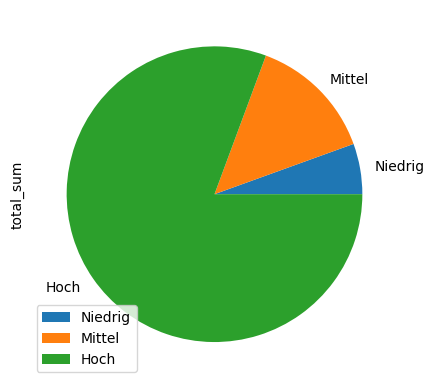

In [31]:
import numpy as np
df['month'] = df['date'].dt.month
df['price_category'] = pd.cut(df['price'], bins = [0, 1000, 2000, float('inf')], labels = ['Niedrig', 'Mittel', 'Hoch'])
df['price_category2'] = np.select([df['price']<500, (df['price'] >= 500) & (df['price'] <= 2000), df['price']>2000], ['Niedrig','Mittel',  'Hoch'], default = '')
df['discount_total'] = (df['total']*0.85).round(2)
x = df.groupby('price_category').agg(total_sum = ('total', 'sum'),
                                         count_ = ('order_id', 'count')).plot(kind='pie', y= 'total_sum')
display(df.groupby('price_category').agg(total_sum = ('total', 'sum'),
                                         count_ = ('order_id', 'count')))


**Schlussfolgerung:** *(Wie ist die Verteilung der Preiskategorien? Wie vereinfacht die Methode pd.cut die Kategorisierung?)*


---
## Aufgabe 10 (Mittel). Pivot-Tabelle

Erstelle eine Pivot-Tabelle mit `pd.pivot_table()`, wobei:
- Zeilen — `city`,
- Spalten — `category`,
- Werte — Summe von `total`,
- Aggregation — `sum`.

Füge Zwischensummen für Zeilen und Spalten hinzu (`margins=True`).


In [32]:
# Dein Code hier
# Dein Code hier
pd.pivot_table(
  df,
  index = 'city',
  columns = 'category',
  values = 'total',
  aggfunc= 'sum',
  margins = True
).round(2).sort_values('All', ascending=False)


category,Bücher,Elektronik,Kleidung,Lebensmittel,Sport,All
city,,,,,,
All,398074.08,428129.79,481992.78,622129.94,405699.34,2336025.93
München,15669.18,44068.06,135537.23,199766.70,105100.00,500141.17
Berlin,87339.03,58713.88,103754.43,118283.10,113742.95,481833.39
Frankfurt,126188.88,154285.60,74340.69,55768.80,43155.08,453739.06
Köln,116118.97,65438.16,31179.87,147336.56,72244.38,432317.94
Hamburg,26773.57,84611.65,90218.24,60466.75,65539.34,327609.56
Unbekannt,25984.45,21012.44,46962.31,40508.03,5917.59,140384.82


**Schlussfolgerung:** *(Welche Stadt und welche Kategorie erzielen den größten Gesamtumsatz? Was zeigen margins?)*


---
## Aufgabe 11 (Mittel). Zählen eindeutiger Werte und Häufigkeiten

1. Zähle die Anzahl der eindeutigen Produkte (`product`) in jeder Kategorie.
2. Gib die Top-5 beliebtesten Produkte nach Bestellanzahl mit `value_counts()` aus.
3. Bestimme den Anteil jeder Zahlungsmethode in Prozent (`normalize=True`).


In [33]:
# Dein Code hier




**Schlussfolgerung:** *(Welche Zahlungsmethode ist am beliebtesten? Ist die Verteilung zwischen den Methoden gleichmäßig?)*


---
## Aufgabe 12 (Mittel). Analyse der Rückgaben

Berechne die Rückgabequote (Anteil der zurückgegebenen Bestellungen) für jede Kategorie und jede Stadt. Bestimme:
- die Kategorie mit der höchsten Rückgabequote,
- die Stadt mit der niedrigsten Rückgabequote.

Tipp: verwende `groupby()['is_returned'].mean()`.


In [34]:
# Dein Code hier




**Schlussfolgerung:** *(Welche Kategorie wird am häufigsten zurückgegeben? Worauf könnte das hindeuten?)*


---
## Aufgabe 13 (Fortgeschritten). Zeitanalyse

1. Setze die Spalte `date` als Index des DataFrames.
2. Berechne den monatlichen Umsatz (Resampling `resample('ME')` oder `resample('M')`, sum über `total`).
3. Finde den besten und den schlechtesten Monat nach Umsatz.
4. Stelle den normalen numerischen Index wieder her (`reset_index()`).


In [35]:
# Dein Code hier




**Schlussfolgerung:** *(Welcher Monat war der erfolgreichste? Gibt es eine Saisonalität in den Daten?)*


---
## Aufgabe 14 (Fortgeschritten). Kumulative Kennzahlen

1. Sortiere den DataFrame nach Datum.
2. Füge die Spalte `cumulative_total` hinzu — kumulativer Umsatz seit Jahresbeginn (`cumsum()`).
3. Bestimme, an welchem Tag 50% des gesamten Jahresumsatzes erreicht wurden.


In [36]:
# Dein Code hier




**Schlussfolgerung:** *(Wann wurde ungefähr die Hälfte des Jahresumsatzes erwirtschaftet? Was bedeutet das für das Geschäft?)*


---
## Aufgabe 15 (Fortgeschritten). apply() und lambda

1. Verwende `apply()` mit einer lambda-Funktion, um die Spalte `total_with_tax` zu erstellen, wobei die Mehrwertsteuer 20% beträgt, aber nur für Bestellungen über 1000 (der Rest bleibt unverändert).
2. Schreibe eine Funktion `classify_rating(r)`, die `'Schlecht'` (1–2), `'Neutral'` (3), `'Gut'` (4–5), `'Ohne Bewertung'` (NaN) zurückgibt. Wende sie auf die Spalte `rating` an.


In [37]:
# Dein Code hier




**Schlussfolgerung:** *(Welcher Anteil der Bestellungen hat eine gute Bewertung? Wann ist apply besser als vektorisierte Operationen?)*


---
## Aufgabe 16 (Fortgeschritten). Zusammenführen von DataFrames (merge)

Erstelle einen zusätzlichen DataFrame `df_discounts` mit den Spalten `category` und `discount_pct` (unterschiedliche Rabatte für jede Kategorie). Führe ihn mit `pd.merge()` mit dem Haupt-DataFrame zusammen und berechne `final_total` — den Betrag nach Anwendung des entsprechenden Rabatts.

```python
df_discounts = pd.DataFrame({
    'category':     ['Elektronik', 'Kleidung', 'Bücher', 'Lebensmittel', 'Sport'],
    'discount_pct': [0.10, 0.20, 0.05, 0.00, 0.15]
})
```


In [38]:
df_discounts = pd.DataFrame({
    'category':     ['Elektronik', 'Kleidung', 'Bücher', 'Lebensmittel', 'Sport'],
    'discount_pct': [0.10, 0.20, 0.05, 0.00, 0.15]
})

# Dein Code hier



**Schlussfolgerung:** *(Welche Kategorie erhielt den größten Gesamtrabatt? Wann sollte man merge statt map verwenden?)*


---
## Aufgabe 17 (Fortgeschritten). Gruppentransformationen

1. Füge die Spalte `city_avg_total` hinzu — durchschnittlicher Bestellbetrag pro Stadt (setze für jede Zeile den Durchschnitt ihrer Stadt ein), verwende `groupby().transform('mean')`.
2. Füge die Spalte `above_city_avg` hinzu — eine boolesche Spalte, die zeigt, ob die Bestellung über dem Stadtdurchschnitt liegt.
3. Berechne den Anteil solcher Bestellungen für jede Stadt.


In [39]:
# Dein Code hier




**Schlussfolgerung:** *(Wodurch unterscheidet sich transform von einem gewöhnlichen groupby? In welcher Stadt ist der Anteil großer Bestellungen am höchsten?)*


---
## Aufgabe 18 (Schwer). Gleitender Durchschnitt und Anomalien

1. Gruppiere die Daten nach Tag und berechne den täglichen Umsatz.
2. Berechne den 7-Tage-gleitenden Durchschnitt des Umsatzes (`rolling(7).mean()`).
3. Bestimme Anomalie-Tage: Tage, an denen der Umsatz mehr als 2 Standardabweichungen vom gleitenden Durchschnitt abweicht.


In [40]:
# Dein Code hier




**Schlussfolgerung:** *(Wie viele Anomalie-Tage wurden gefunden? Was könnte die Ursache für starke Umsatzschwankungen sein?)*


---
## Aufgabe 19 (Schwer). Kohortenanalyse

Führe eine vereinfachte Kohortenanalyse nach dem Monat der Erstbestellung durch:
1. Finde für jedes Produkt (`product`) den Monat des ersten Verkaufs — das ist seine „Kohorte“.
2. Führe diese Information mit dem Haupt-DataFrame zusammen.
3. Erstelle eine Pivot-Tabelle: Kohorte (Monat des ersten Verkaufs) gegen Bestellmonat, Werte — Anzahl der Bestellungen.

Tipp: verwende `groupby('product')['date'].transform('min')` und `dt.to_period('M')`.


In [41]:
# Dein Code hier




**Schlussfolgerung:** *(Was zeigt die Kohortentabelle? Verkaufen sich Produkte aus der ersten Kohorte auch in den folgenden Monaten weiter?)*


---
## Aufgabe 20 (Schwer). Abschlussbericht

Erstelle einen Abschlussbericht als einen einzigen DataFrame `summary_report`, der für jede Kategorie enthält:
- den Gesamtumsatz (`total_revenue`),
- die Anzahl der Bestellungen (`order_count`),
- den durchschnittlichen Bon (`avg_order_value`),
- den Umsatzanteil am Gesamtumsatz (`revenue_share_pct`),
- die Rückgabequote in Prozent (`return_rate_pct`),
- die durchschnittliche Bewertung ohne NaN (`avg_rating`).

Sortiere absteigend nach `total_revenue`. Speichere das Ergebnis in der Datei `summary_report.csv`.


In [42]:
# Dein Code hier




**Schlussfolgerung:** *(Welche Kategorie ist Umsatzführer? Gibt es einen Zusammenhang zwischen Bewertung und Rückgabequote? Welche Empfehlungen lassen sich basierend auf diesem Bericht für das Geschäft geben?)*


---
## Allgemeines Fazit

Beantworte nach Abschluss aller Aufgaben folgende Fragen:

1. Welche pandas-Methoden waren für dich am nützlichsten?
2. Welche Schwierigkeiten sind bei der Arbeit mit fehlenden Werten aufgetreten?
3. Was könnte man der Analyse hinzufügen, um sie vollständiger zu machen?

*(Deine Antworten hier)*
